<a href="https://colab.research.google.com/github/aminmoosavi/__PyTorch__/blob/main/PyTorch_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Day-1**

* **In this notebook we will practice what we learned in Day-0 and implement a quadratic regression model**


In [ ]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

**PyTorch Version**


In [ ]:
torch.__version__

'2.11.0+cpu'

 **Check for the GPU**

 NVIDIA System Management Interface (smi)

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


* # Creating the data
We are looking at a quadratic model with Gaussian noise ($\eta$)

$ y = ax^2 +bx +c + \eta$

The goal is to find the parameters $a,b,c$ using PyTorch

In [ ]:
# True parameters
a = 1.0
b = -2.0
c = 4.0

# Input data
X = torch.arange(start = -2 , end = 4 , step = 0.01)

# Observed output
Y = a * X**2 + b * X + c + torch.randn(X.size())

* # Splitting the data into Training and Test sets

In [ ]:
# Generating a shuffled data indices
shuffled_indices = torch.randperm(X.size()[0])

# Use 75 percent of the data points for training and 25 percent for testing
# We could have a validation set (Will get back to this in the future)
train_split = int(0.75 * len(X))

# Splitting the data
X_train , Y_trian = X[shuffled_indices[:train_split]] , Y[shuffled_indices[:train_split]]
X_test , Y_test = X[shuffled_indices[train_split:]] , Y[shuffled_indices[train_split:]]

* # Visualize the data

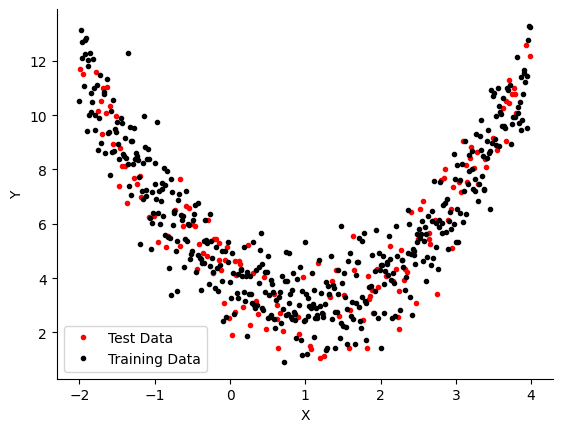

In [ ]:
fig, ax = plt.subplots()
ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

* # Build the model

In [ ]:
class QuadraticRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.a = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32 ))
    self.b = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32 ))
    self.c = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32 ))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.a * x**2 + self.b * x + self.c


* # Instantiate the model

In [ ]:
torch.manual_seed(43)
model_1 = QuadraticRegressionModel()

* # Select the loss function

In [ ]:
# Mean Squared Error loss function:
loss_fn = nn.MSELoss()

* # Select the optimizer

In [ ]:
# The SGD optimizer. lr is the learning rate
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.02)

* # The training loop

In [ ]:
epochs = 150
losses=torch.zeros(epochs)
losses_test=torch.zeros(epochs)
for epoch in range(epochs):
  model_1.train() # training mode activated

  #1. forward pass
  Y_pred = model_1(X_train)

  #2. Compute the loss
  loss=loss_fn(Y_pred,Y_trian)
  losses[epoch]=loss # save the loss

  #3. Optimizer zero grad resets the gradient to zero
  optimizer.zero_grad()

  #4. Perform backpropagation
  loss.backward()

  #5. Step the optimizer (gradient descent)
  optimizer.step()

  #6. Look at how the model does on the test data
  model_1.eval() # Evaluation mode activated
  with torch.inference_mode():
    # forward pass the test data
    Y_pred_test = model_1(X_test)

    # calculate test loss
    loss_test=loss_fn(Y_pred_test,Y_test)
    losses_test[epoch] = loss_test # save the loss

* # Visualize loss during training

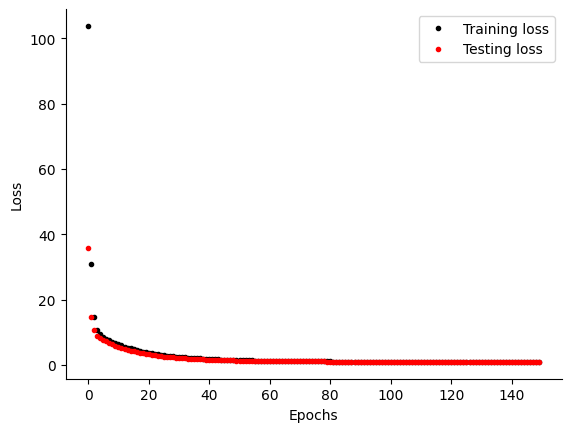

In [ ]:
# Casting the loss tensors into NumPy arrays
lossvals=losses.detach().numpy()
lossvals_test=losses_test.detach().numpy()

# Plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals,'.',color='k',label = 'Training loss')
ax.plot(lossvals_test,'.',color='r',label = 'Testing loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

* # Testing

* **Looking at model parameters and compare with the true values**

In [ ]:
print('Estimated a=',model_1.a.item() ,  '------- True a = ', a)
print('Estimated b=',model_1.b.item() ,  '------- True b = ' , b)
print('Estimated a=',model_1.c.item() ,  '------- True a = ', c)

Estimated a= 1.0272616147994995 ------- True a =  1.0
Estimated b= -2.0704593658447266 ------- True b =  -2.0
Estimated a= 3.9629108905792236 ------- True a =  4.0


* **Looking at model predictions**

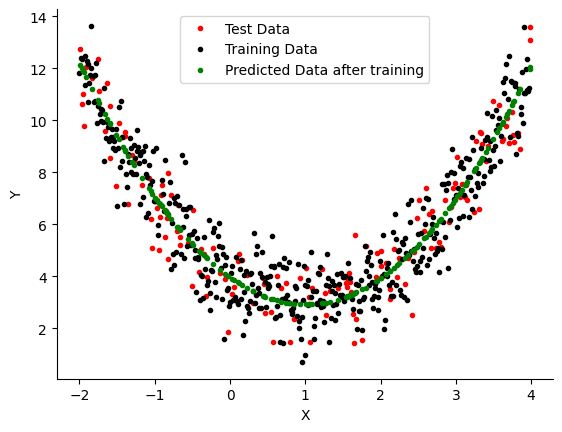

In [ ]:
with torch.inference_mode():
  y_preds = model_1(X_test)
fig, ax = plt.subplots()

ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
ax.plot(X_test,y_preds,'g.',label='Predicted Data after training')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()